## Your Group (*Update this Information*)

Submitted by Group 11:

- Ehsan Attar
- Reihaneh Akbarifard
- Maryam Pours Salman Ahvazi
- Ramin Shahbazi

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

In [1]:
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from PIL import Image

<p style="page-break-after:always;"></p>

# Helper Function

In [2]:
  
def plot_distribution(*outputs, figsize=None):
    if figsize is None:
        figsize = (5 * len(outputs), 3)
    plt.figure(figsize=figsize)
    for i, out in enumerate(outputs):
        prefix = f"{i+1}. "
        plt.subplot(1,len(outputs),i+1)
        plt.title(f"{prefix}Shape={out.shape}; Max={out.max():.4f}@{out.argmax()}")
        if out.sum() < 0.99999999:
            print("WARNING: Sum not 1, but should be. Sum={out.sum():.4f}")
        plt.plot(out)
    plt.show()

In [3]:
def plot_trajectory(
    trajectory,
    measurements=None,
    true_path=None,
    estimate_label="Estimate",
    measurement_label="Measurements",
    true_label="True Path",
    title="2D Tracking",
    start_label="Start",
    end_label="End",
    show_measurements=True,
    show_true_path=True,
    figsize=(6, 6)
):
    trajectory = np.array(trajectory)

    if measurements is not None:
        measurements = np.array(measurements)

    if true_path is not None:
        true_path = np.array(true_path)

    plt.figure(figsize=figsize)

    # estimated path
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linewidth=2,
        label=estimate_label
    )

    # measurements
    if show_measurements and measurements is not None:
        plt.scatter(
            measurements[:, 0],
            measurements[:, 1],
            s=10,
            alpha=0.4,
            label=measurement_label
        )

    # true path
    if show_true_path and true_path is not None:
        plt.plot(
            true_path[:, 0],
            true_path[:, 1],
            'k--',
            linewidth=2,
            label=true_label
        )

    # start and end markers
    plt.scatter(trajectory[0, 0], trajectory[0, 1], c="green", label=start_label)
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], c="red", label=end_label)

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.axis("equal")
    plt.grid()
    plt.legend()
    plt.show()

<p style="page-break-after:always;"></p>

# Task: Kalman Filter
---

Above example is actually a quite amazing example, because we can localize the train without any idea where it is and even the measurements give us just a multimodal distribution where we could be. Just by combining all information the train can be localized.

In the next case, we have a much simpler problem setting (despite a more complicated explanation), which allows us to implement a more efficient and fast solution: The Kalman Filter.
It is used to predict the state of a linear system with gaussian distribution.

Imagine an autonomous robot driving indoors.
* The state is the position of the robot $x = (p_x, p_y)$. And the state does not change without control input $\rightarrow A = I$ (identity matrix for state transition matrix). 
* The robot can move in x and y direction resulting in a control sequence $u = (v_x, v_y)$. The velocity is linearily applied assuming a constant time delay ($\Delta_t$) $\rightarrow B = \Delta_t \cdot I$.
* As measurements we can measure $z$ using a measurement function $H$ (H defined later): $z = Hx$.

The matrices $A$ and $B$ would be:
$$
A =
\left[ {\begin{array}{cc}
1 & 0 \\
0 & 1 \\
\end{array} } \right]
$$

$$
B =
\left[ {\begin{array}{cc}
\Delta_t & 0 \\
0 & \Delta_t \\
\end{array} } \right]
$$

<div style="background-color: #042c58; color: #ffffff; width: 100%; padding: 0.3em; font-size:1.1em; font-weight: bold;">Definition: Kalman Filter</div>
<div style="background-color: #d7e9fd; width: 100%; padding-top: 0.5em; padding-bottom: 0.3em">
    
**Time Update** (aka Prediction) step using $A, B, x, u$, estimated system covariance matrix $\hat{C}$ and motion covariance matrix $C^u$.

$$x \leftarrow A x + B u$$

$$\hat{C} \leftarrow A \hat{C} A^T + C^u$$

**Measurement Update** (aka Measurement) step of the kalman filter using $H, x, z$, estimated system covariance matrix $\hat{C}$ and measurement covariance matrix $C^m$. Define an intermediate variable for the Kalman Gain $K$.

$$K = \hat{C} H^T (H \hat{C} H^T + C^m)^{-1}$$

$$ x \leftarrow x + K ( z - Hx)$$

$$\hat{C} \leftarrow (I-KH)\hat{C}$$

</div>

In [4]:
# Covariance for measurement and motion
C_u = np.array([
    [0.2, 0],
    [0, 0.2]
])
C_m = np.array([
    [0.2, 0.01],
    [0.01, 0.2]
])
H = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

# State transition A = I and control matrix B = dt * I (dt = 1)
dt = 1.0
A = np.eye(2)
B = dt * np.eye(2)

# Implement the filter
def predict(x, C_hat, u):
    # Time update: propagate the state and inflate the covariance by motion noise
    x = A @ x + B @ u
    C_hat = A @ C_hat @ A.T + C_u
    return x, C_hat

def measure(x, C_hat, z):
    # Measurement update: Kalman gain, state correction, covariance shrink
    K = C_hat @ H.T @ np.linalg.inv(H @ C_hat @ H.T + C_m)
    x = x + K @ (z - H @ x)
    C_hat = (np.eye(2) - K @ H) @ C_hat
    return x, C_hat

# Initial estimate (wide distribution as we have no clue)
x = np.array([5.,5.])
C_hat = np.array([
    [10., 0.],
    [0., 10.]
])


X_True [7. 5.]
Pred [8. 6.] [10.2  0.   0.  10.2]
Measure [7.02017291 5.02017291] [ 0.35378811 -0.14802442 -0.14802442  0.35378811]
X_True [4. 8.]
Pred [4.02017291 8.02017291] [ 0.55378811 -0.14802442 -0.14802442  0.55378811]
Measure [4.00687977 8.00687977] [ 0.21981051 -0.0814289  -0.0814289   0.21981051]
X_True [5. 6.]
Pred [5.00687977 6.00687977] [ 0.41981051 -0.0814289  -0.0814289   0.41981051]
Measure [5.00263457 6.00263457] [ 0.19333237 -0.06375082 -0.06375082  0.19333237]
X_True [6. 3.]
Pred [6.00263457 3.00263457] [ 0.39333237 -0.06375082 -0.06375082  0.39333237]
Measure [6.00102535 3.00102535] [ 0.1866083 -0.0583383 -0.0583383  0.1866083]


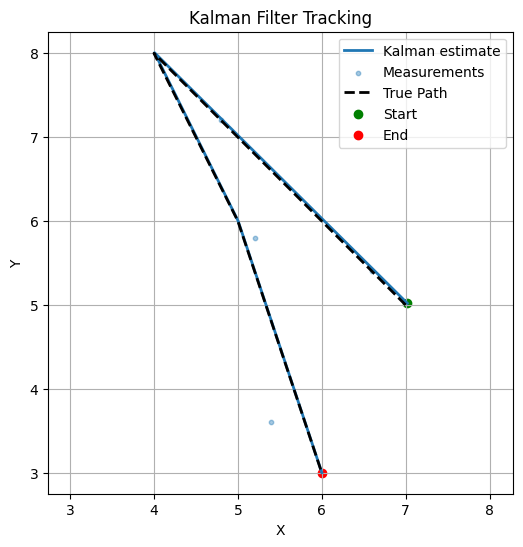

In [5]:
# Simulate, print intermediate results, and plot the final trajectory
x_true = np.array([4., 4.])
motions = np.array([
    [3., 1.],
    [-3., 3.],
    [1., -2.],
    [1., -3.],
])

true_hist = []
meas_hist = []
est_hist = []

for i, u in enumerate(motions):
    x_true += u
    z = np.dot(H, x_true)

    print(f"X_True {x_true}")
    x, C_hat = predict(x, C_hat, u)
    print("Pred", x, C_hat.flatten())
    x, C_hat = measure(x, C_hat, z)
    print("Measure", x, C_hat.flatten())

    true_hist.append(x_true.copy())
    meas_hist.append(z.copy())
    est_hist.append(x.copy())

true_hist = np.array(true_hist)
meas_hist = np.array(meas_hist)
est_hist = np.array(est_hist)

plot_trajectory(
    est_hist,
    measurements=meas_hist,
    true_path=true_hist,
    estimate_label='Kalman estimate',
    title='Kalman Filter Tracking'
)


# Extended Kalman Filter (EKF) — 2D Robot Tracking

## Objective

In this task, you will implement an Extended Kalman Filter for a robot moving in 2D.
The robot state contains both position and velocity:
$$
 x = [p_x, p_y, v_x, v_y]^T
$$

## System overview
- state dimension: 4
- measurement dimension: 2
- process noise covariance: $Q \in \mathbb{R}^{4*4}$
- measurement noise covariance: $R \in \mathbb{R}^{2*2}$

We use the same structure as before:
1. define the motion model,
2. define the measurement model,
3. compute the Jacobians,
4. implement prediction,
5. implement measurement update,
6. visualize the result.


### (a) Motion Model

Use a constant-velocity model with time step `dt`:
$$
 p_x' = p_x + v_x dt, \qquad p_y' = p_y + v_y dt
$$
$$
 v_x' = v_x, \qquad v_y' = v_y
$$


In [6]:
dt = 1.0

def f(x):
    px, py, vx, vy = x

    # Constant-velocity motion model
    return np.array([
        px + vx * dt,
        py + vy * dt,
        vx,
        vy
    ])


def F_jacobian(x):
    px, py, vx, vy = x

    # Jacobian of f w.r.t. the state [px, py, vx, vy].
    # The model is linear, so the Jacobian is constant.
    return np.array([
        [1.0, 0.0,  dt, 0.0],
        [0.0, 1.0, 0.0,  dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])


### (b) Measurement Model

We measure position only:
$$
 h(x) = [p_x, p_y]^T
$$


In [7]:
def h(x):
    # We observe position only
    return np.array([x[0], x[1]])


def H_jacobian(x):
    # Jacobian of h w.r.t. the state: picks out px and py
    return np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0]
    ])


### (c) Prediction Step


In [8]:
def ekf_predict(x, P, Q):
    # Propagate the state through the (non)linear motion model
    x_pred = f(x)

    # Linearize the motion model around the current state
    F = F_jacobian(x)

    # Propagate the covariance and add process noise
    P_pred = F @ P @ F.T + Q

    return x_pred, P_pred


### (d) Measurement Update Step


In [9]:
def ekf_update(x_pred, P_pred, z, R):
    # Predicted measurement from the predicted state
    z_pred = h(x_pred)

    # Linearize the measurement model
    H = H_jacobian(x_pred)

    # Innovation (measurement residual)
    y = z - z_pred

    # Innovation covariance
    S = H @ P_pred @ H.T + R

    # Kalman gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # State update
    x_upd = x_pred + K @ y

    # Covariance update
    P_upd = (np.eye(4) - K @ H) @ P_pred

    return x_upd, P_upd


### Run the Filter

Initialization matters.
Use a meaningful prior for the state and covariance, then complete the prediction and correction calls in the loop.


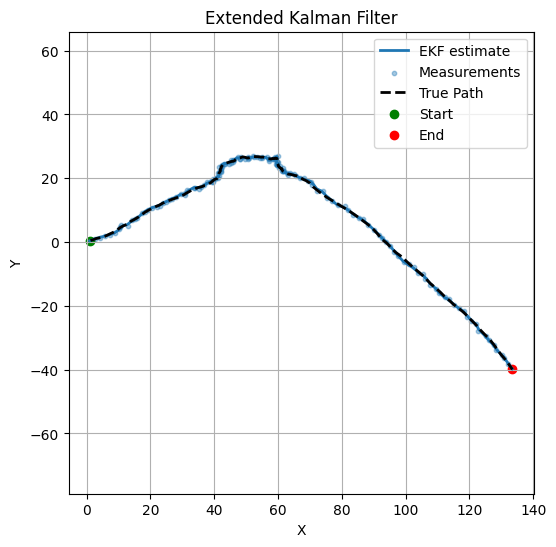

In [10]:
Q = 0.01 * np.eye(4)
R = 0.1 * np.eye(2)

# Prior: reasonable guess of the initial state and a moderate covariance
x = np.array([0.0, 0.0, 1.0, 0.5])
P = np.eye(4)

trajectory = []
measurements = []
true_path = []

x_true = np.array([0.0, 0.0, 1.0, 0.5])

for _ in range(150):
    x_true = f(x_true) + np.random.multivariate_normal(np.zeros(4), Q)
    z = h(x_true) + np.random.multivariate_normal(np.zeros(2), R)

    # prediction
    x_pred, P_pred = ekf_predict(x, P, Q)

    # update
    x, P = ekf_update(x_pred, P_pred, z, R)

    trajectory.append(x.copy())
    measurements.append(z.copy())
    true_path.append(x_true.copy())

trajectory = np.array(trajectory)
measurements = np.array(measurements)
true_path = np.array(true_path)

plot_trajectory(
    trajectory[:, :2],
    measurements=measurements,
    true_path=true_path[:, :2],
    estimate_label='EKF estimate',
    title='Extended Kalman Filter'
)


# Particle Filter

## Objective

Implement a particle filter for the same robot model.
In contrast to the Kalman filter and EKF, the particle filter approximates the posterior with weighted samples.


### (a) Motion model


In [11]:
N = 500
T = 100
Q = 0.05 * np.eye(4)
R = 0.2 * np.eye(2)

def motion_model(x):
    px, py, vx, vy = x

    # Constant-velocity model (dt = 1)
    return np.array([
        px + vx,
        py + vy,
        vx,
        vy
    ])


### (b) Measurement Model


In [12]:
def measurement_model(x):
    # We observe position only
    return np.array([x[0], x[1]])


### (c) Particle Initialization

Initialize particles around a reasonable prior.
For example, you may sample position and velocity from Gaussian distributions around your best guess.


In [13]:
particles = np.zeros((N, 4))

# Initialize particles as Gaussian samples around a reasonable prior.
# Prior mean matches the true initial state; larger spread on position than velocity.
prior_mean = np.array([0.0, 0.0, 1.0, 0.5])
prior_std = np.array([1.0, 1.0, 0.5, 0.5])
particles = prior_mean + np.random.randn(N, 4) * prior_std

weights = np.ones(N) / N


### (d) Gaussian Likelihood

Implement the importance weights using a Gaussian likelihood in measurement space.
Normalize the weights so that they sum to 1.


In [14]:
def update_weights(particles, z, R):
    """
    Inputs:
        particles: (N, 4)
        z: measurement (2,)
        R: measurement covariance (2, 2)

    Output:
        normalized weights of shape (N,)
    """
    # Expected measurement for each particle (position only)
    expected = particles[:, :2]              # (N, 2)
    diff = z - expected                       # (N, 2)

    # Gaussian likelihood: exp(-0.5 * diff^T R^-1 diff) per particle
    R_inv = np.linalg.inv(R)
    exponent = -0.5 * np.einsum('ni,ij,nj->n', diff, R_inv, diff)
    weights = np.exp(exponent)

    # Normalize (guard against underflow to all-zeros)
    weights += 1e-300
    weights /= np.sum(weights)
    return weights


### (e) Resampling

Implement a resampling strategy so that high-weight particles are duplicated more often than low-weight particles.


In [15]:
def resample(particles, weights):
    """
    Inputs:
        particles: (N, 4)
        weights: (N,)

    Output:
        resampled particles
    """
    N = len(particles)
    # Draw N indices with probability proportional to the weights.
    # High-weight particles get selected (duplicated) more often.
    idx = np.random.choice(N, size=N, p=weights)
    return particles[idx].copy()


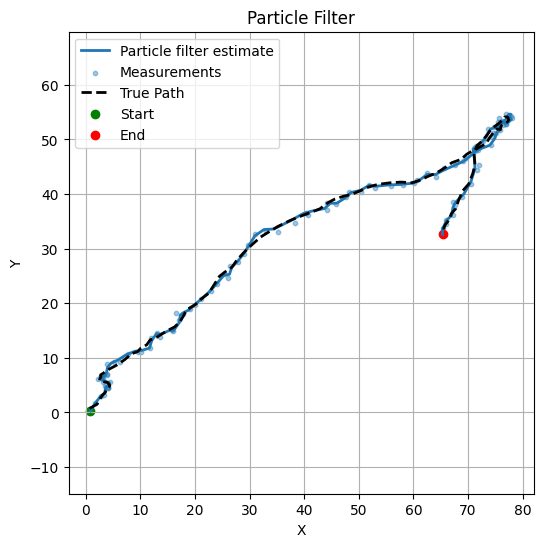

In [16]:
true_state = np.array([0.0, 0.0, 1.0, 0.5])

true_hist = []
est_hist = []
meas_hist = []

for _ in range(T):
    true_state = motion_model(true_state)
    true_state += np.random.multivariate_normal(np.zeros(4), Q)

    z = measurement_model(true_state)
    z += np.random.multivariate_normal(np.zeros(2), R)

    for i in range(N):
        particles[i] = motion_model(particles[i]) + np.random.multivariate_normal(np.zeros(4), Q)

    weights = update_weights(particles, z, R)
    x_est = np.average(particles, axis=0, weights=weights)

    particles = resample(particles, weights)
    weights = np.ones(N) / N

    true_hist.append(true_state.copy())
    est_hist.append(x_est.copy())
    meas_hist.append(z.copy())

true_hist = np.array(true_hist)
est_hist = np.array(est_hist)
meas_hist = np.array(meas_hist)

plot_trajectory(
    est_hist[:, :2],
    measurements=meas_hist,
    true_path=true_hist[:, :2],
    estimate_label='Particle filter estimate',
    title='Particle Filter'
)


# Particle Resampling


In [17]:
particles_1d = np.random.uniform(0, 50, 500)
weights_1d = np.exp(-0.5 * ((particles_1d - 25) / 2) ** 2)
weights_1d /= np.sum(weights_1d)


In [18]:
def resample_particles_1d(particles, weights):
    # Sample indices in [0, len(particles)) with probability given by the weights
    idx = np.random.choice(
        len(particles),
        size=len(particles),
        p=weights
    )
    return particles[idx]


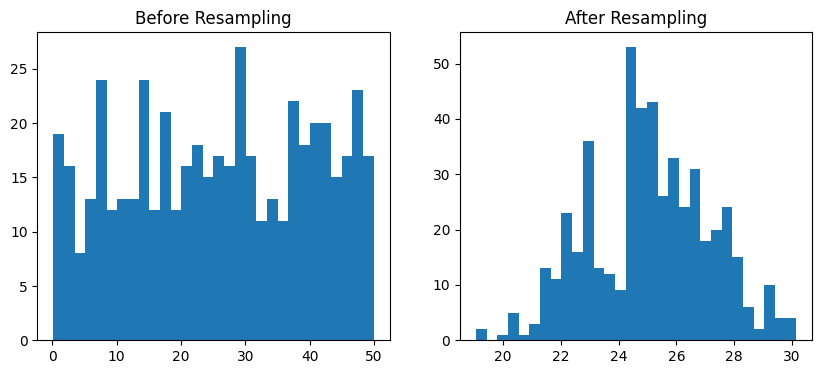

In [19]:
resampled = resample_particles_1d(particles_1d, weights_1d)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(particles_1d, bins=30)
plt.title('Before Resampling')

plt.subplot(1, 2, 2)
plt.hist(resampled, bins=30)
plt.title('After Resampling')
plt.show()
